# Stock Market Trend Analysis

### Predictive Analytics & Trading Signal Engine

### Week 1. Part 3: Exploratory Data Analysis (EDA)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
df_indicators = pd.read_csv("stock_prices_with_indicators.csv")

In [6]:
df_comp = pd.read_csv("company_info.csv")

In [7]:
df_stock = pd.read_csv("stock_prices.csv")

In [8]:
df_market = pd.read_csv("market_indices.csv")

#### Preparing the data for the EDA

In [10]:
df_comp.head(2)

,ticker,company_name,sector,ipo_date
0,STK001,TechCorp,Technology,2021-04-10
1,STK002,DataSystems,Technology,2016-10-12


In [11]:
df_indicators.head(2)

,ticker,date,open,high,low,close,volume,adjusted_close,sma_20,sma_50,...,true_range,atr_14,volume_sma_20,volume_ratio,momentum_10,momentum_20,price_to_sma_50,volatility_20,future_return_5d,trend_label
0,STK001,2021-01-04,158.09,160.97,158.09,160.11,962644.0,160.11,160.110,160.110,...,2.88,2.880,962644.0,1.000000,NaN,NaN,0.000000,NaN,0.026357,Uptrend
1,STK001,2021-01-05,163.16,165.50,160.76,162.36,1312685.0,162.36,161.235,161.235,...,5.39,4.135,1137664.5,1.153842,NaN,NaN,0.006977,NaN,0.018169,Sideways


In [12]:
# Merging "company_info" with "stock_prices_with_indicators" datasets
# df_comp = company_info dataset and df_indicators= stock_prices_with_indicators

merged_df = pd.merge(df_comp, df_indicators, on="ticker", how="outer")  # Performing full outer join on "ticker"

In [13]:
merged_df.head(2)

,ticker,company_name,sector,ipo_date,date,open,high,low,close,volume,...,true_range,atr_14,volume_sma_20,volume_ratio,momentum_10,momentum_20,price_to_sma_50,volatility_20,future_return_5d,trend_label
0,STK001,TechCorp,Technology,2021-04-10,2021-01-04,158.09,160.97,158.09,160.11,962644.0,...,2.88,2.880,962644.0,1.000000,NaN,NaN,0.000000,NaN,0.026357,Uptrend
1,STK001,TechCorp,Technology,2021-04-10,2021-01-05,163.16,165.50,160.76,162.36,1312685.0,...,5.39,4.135,1137664.5,1.153842,NaN,NaN,0.006977,NaN,0.018169,Sideways


In [14]:
# saving the merged file to a new csv

merged_df.to_csv("merged_dataset_for_eda.csv", index=False)

In [15]:
# Loading the merged_dataset_for_eda

df = pd.read_csv("merged_dataset_for_eda.csv")

In [16]:
df.head(2)

,ticker,company_name,sector,ipo_date,date,open,high,low,close,volume,...,true_range,atr_14,volume_sma_20,volume_ratio,momentum_10,momentum_20,price_to_sma_50,volatility_20,future_return_5d,trend_label
0,STK001,TechCorp,Technology,2021-04-10,2021-01-04,158.09,160.97,158.09,160.11,962644.0,...,2.88,2.880,962644.0,1.000000,NaN,NaN,0.000000,NaN,0.026357,Uptrend
1,STK001,TechCorp,Technology,2021-04-10,2021-01-05,163.16,165.50,160.76,162.36,1312685.0,...,5.39,4.135,1137664.5,1.153842,NaN,NaN,0.006977,NaN,0.018169,Sideways


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15502 entries, 0 to 15501
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ticker            15502 non-null  object 
 1   company_name      15502 non-null  object 
 2   sector            15502 non-null  object 
 3   ipo_date          15502 non-null  object 
 4   date              15502 non-null  object 
 5   open              15502 non-null  float64
 6   high              15502 non-null  float64
 7   low               15502 non-null  float64
 8   close             15502 non-null  float64
 9   volume            15502 non-null  float64
 10  adjusted_close    15502 non-null  float64
 11  sma_20            15192 non-null  float64
 12  sma_50            15502 non-null  float64
 13  sma_200           15502 non-null  float64
 14  ema_12            15502 non-null  float64
 15  ema_26            15502 non-null  float64
 16  macd              15191 non-null  float6

In [18]:
# Converting dates columns to datetime format for time-series analysis

df["ipo_date"] = pd.to_datetime(df["ipo_date"])

df["date"] = pd.to_datetime(df["date"])

In [19]:
# Handling missing values

df.isna().sum()

ticker                0
company_name          0
sector                0
ipo_date              0
date                  0
open                  0
high                  0
low                   0
close                 0
volume                0
adjusted_close        0
sma_20              310
sma_50                0
sma_200               0
ema_12                0
ema_26                0
macd                311
macd_signal           0
macd_histogram        0
rsi_14              330
bb_middle             0
bb_upper             20
bb_lower             20
bb_width            331
true_range            0
atr_14                0
volume_sma_20         0
volume_ratio        310
momentum_10         200
momentum_20         400
price_to_sma_50       0
volatility_20        40
future_return_5d      0
trend_label           0
dtype: int64

In [20]:
df.isnull().mean()*100

ticker              0.000000
company_name        0.000000
sector              0.000000
ipo_date            0.000000
date                0.000000
open                0.000000
high                0.000000
low                 0.000000
close               0.000000
volume              0.000000
adjusted_close      0.000000
sma_20              1.999742
sma_50              0.000000
sma_200             0.000000
ema_12              0.000000
ema_26              0.000000
macd                2.006193
macd_signal         0.000000
macd_histogram      0.000000
rsi_14              2.128758
bb_middle           0.000000
bb_upper            0.129016
bb_lower            0.129016
bb_width            2.135208
true_range          0.000000
atr_14              0.000000
volume_sma_20       0.000000
volume_ratio        1.999742
momentum_10         1.290156
momentum_20         2.580312
price_to_sma_50     0.000000
volatility_20       0.258031
future_return_5d    0.000000
trend_label         0.000000
dtype: float64

In [21]:
# Imputing missing values with mean

columns_to_impute = ['sma_20', 'macd', 'rsi_14', 'bb_upper', 'bb_lower', 'bb_width', 'volume_ratio', 'momentum_10', 
                     'momentum_20', 'volatility_20']

for col in columns_to_impute:
    df[col] = df[col].fillna(df[col].mean())

In [22]:
df.isnull().sum()

ticker              0
company_name        0
sector              0
ipo_date            0
date                0
open                0
high                0
low                 0
close               0
volume              0
adjusted_close      0
sma_20              0
sma_50              0
sma_200             0
ema_12              0
ema_26              0
macd                0
macd_signal         0
macd_histogram      0
rsi_14              0
bb_middle           0
bb_upper            0
bb_lower            0
bb_width            0
true_range          0
atr_14              0
volume_sma_20       0
volume_ratio        0
momentum_10         0
momentum_20         0
price_to_sma_50     0
volatility_20       0
future_return_5d    0
trend_label         0
dtype: int64

In [23]:
# Checking for duplicates in the merged data set for eda

df.duplicated().sum()

np.int64(0)

#### 1. Price Trend Analysis

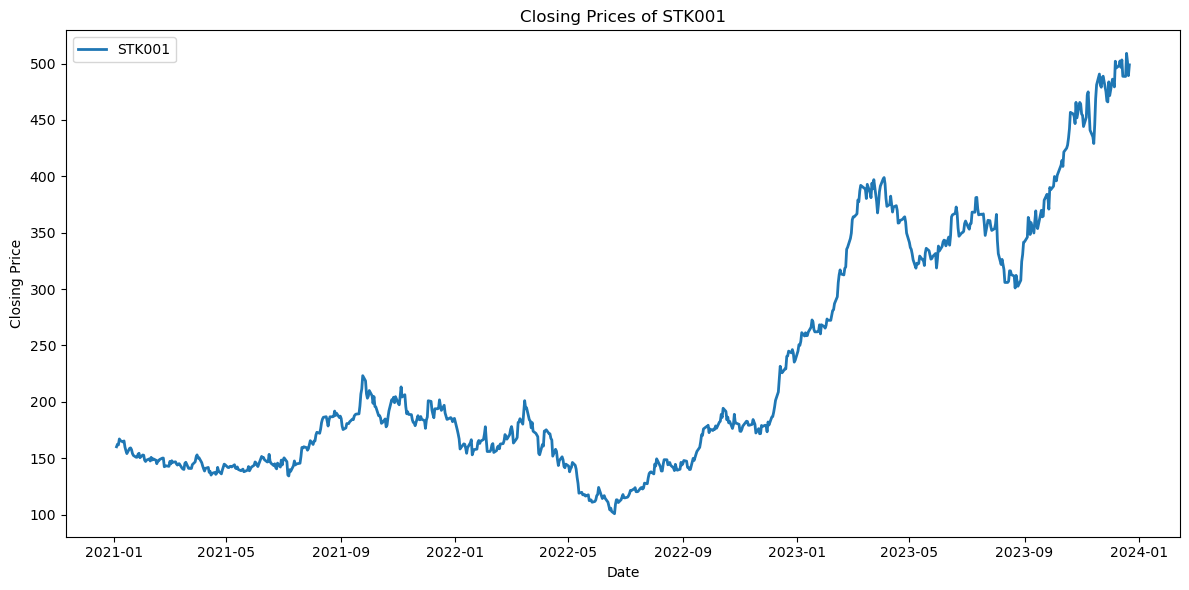

In [25]:
# a. Closing prices for STK001

plt.figure(figsize=(12,6))
sns.lineplot(x="date", y="close", data=df[df["ticker"]=="STK001"], label='STK001', linewidth=2)
plt.title("Closing Prices of STK001")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.tight_layout()
plt.show()

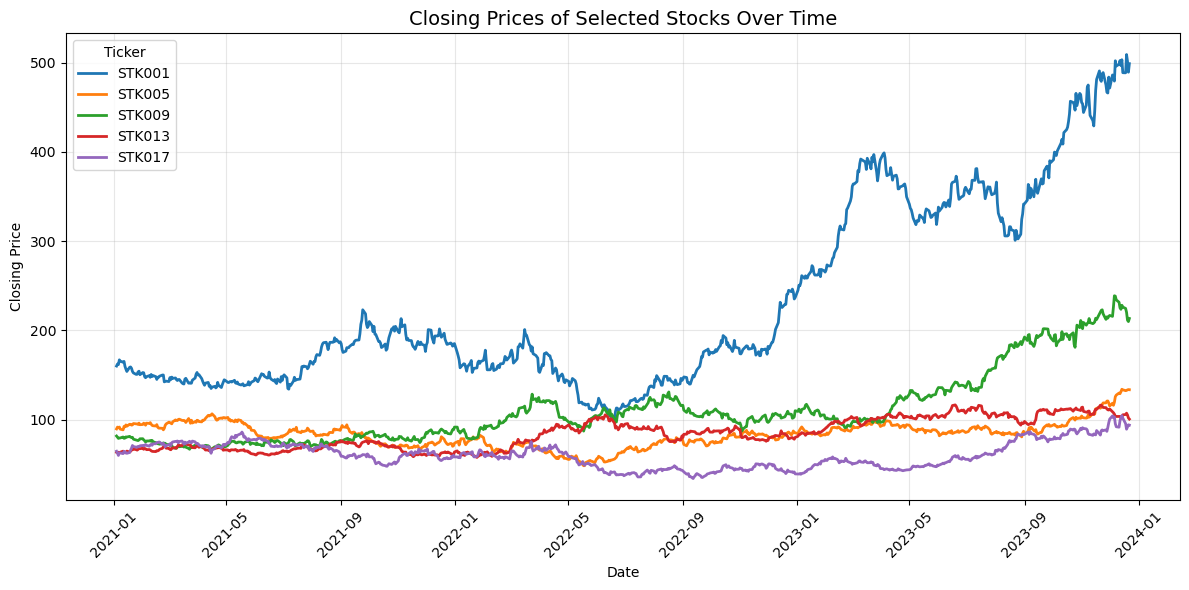

In [26]:

# Define the list of tickers to compare
tickers = ['STK001', 'STK005', 'STK009', 'STK013', 'STK017']

# Filter only the selected tickers
subset = df[df['ticker'].isin(tickers)].sort_values(['ticker', 'date'])

# Create the plot
plt.figure(figsize=(12, 6))

# Loop through each stock and plot its closing price
for ticker in tickers:
    stock_data = subset[subset['ticker'] == ticker]
    plt.plot(stock_data['date'], stock_data['close'], label=ticker, linewidth=2)

# Add labels and title
plt.title('Closing Prices of Selected Stocks Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend(title='Ticker', loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [27]:
# c. Basic Statistics of returns

df["future_return_5d"].describe()

count    15502.000000
mean         0.002466
std          0.053491
min         -0.635318
25%         -0.030752
50%          0.002061
75%          0.035708
max          0.245885
Name: future_return_5d, dtype: float64

In [28]:
# c. Basic Statistics of returns of 5 selected stocks

subset.groupby("ticker")["future_return_5d"].describe()

,count,mean,std,min,25%,50%,75%,max
ticker,,,,,,,,
STK001,775.0,0.008689,0.054994,-0.186457,-0.027974,0.009166,0.042409,0.214552
STK005,775.0,0.003461,0.046841,-0.166750,-0.027810,0.002624,0.033466,0.169380
STK009,775.0,0.007960,0.051096,-0.150419,-0.029149,0.004193,0.041132,0.179102
STK013,775.0,0.004003,0.043943,-0.146501,-0.023554,0.004070,0.030155,0.170193
STK017,775.0,0.004765,0.064227,-0.154502,-0.038207,0.003701,0.048027,0.232303


#### 2. Sector Comparison

In [30]:
# a. Average returns by sector (in Percentage)

df.groupby("sector")["future_return_5d"].mean()*100

sector
Consumer      0.256618
Energy        0.164161
Finance       0.361039
Healthcare    0.220237
Technology    0.230832
Name: future_return_5d, dtype: float64

In [31]:
avg_sector_return = df.groupby("sector")["future_return_5d"].mean()*100

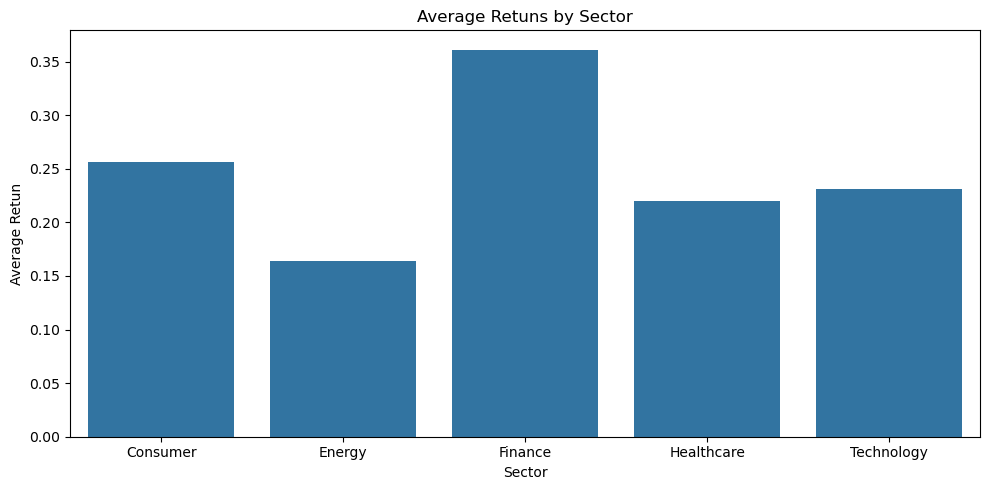

In [32]:
# Average returns by sector (in Percentage)

plt.figure(figsize=(10,5))
sns.barplot(x="sector", y="future_return_5d", data=avg_sector_return.reset_index(name="future_return_5d"))

plt.title("Average Retuns by Sector")
plt.xlabel("Sector")
plt.ylabel("Average Retun")
plt.tight_layout()
plt.show()

In [33]:
# b. Volatility across sector comparison in Percentage

df.groupby("sector")["volatility_20"].mean()*100

sector
Consumer      1.789390
Energy        3.019658
Finance       2.226139
Healthcare    2.015803
Technology    2.431475
Name: volatility_20, dtype: float64

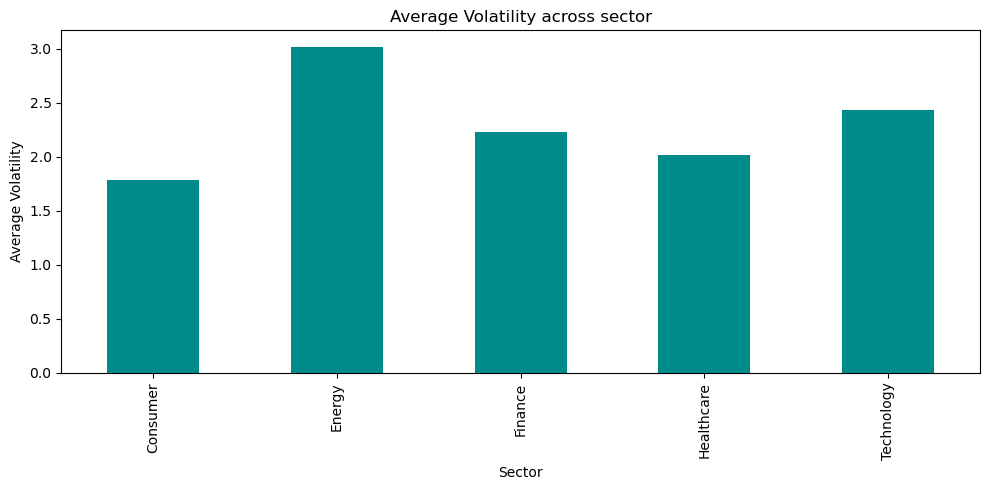

In [34]:
# Volatility across sector comparison in Percentage

Avg_sector_volatility = df.groupby("sector")["volatility_20"].mean()*100

Avg_sector_volatility.plot(figsize=(10,5), kind="bar", color="darkcyan")

plt.title("Average Volatility across sector")
plt.xlabel("Sector")
plt.ylabel("Average Volatility")
plt.tight_layout()
plt.show()

In [35]:
df["volatility_20"].describe()

count    15502.000000
mean         0.022965
std          0.007035
min          0.001749
25%          0.017988
50%          0.022006
75%          0.026893
max          0.065473
Name: volatility_20, dtype: float64

In [36]:
df["future_return_5d"].describe()

count    15502.000000
mean         0.002466
std          0.053491
min         -0.635318
25%         -0.030752
50%          0.002061
75%          0.035708
max          0.245885
Name: future_return_5d, dtype: float64

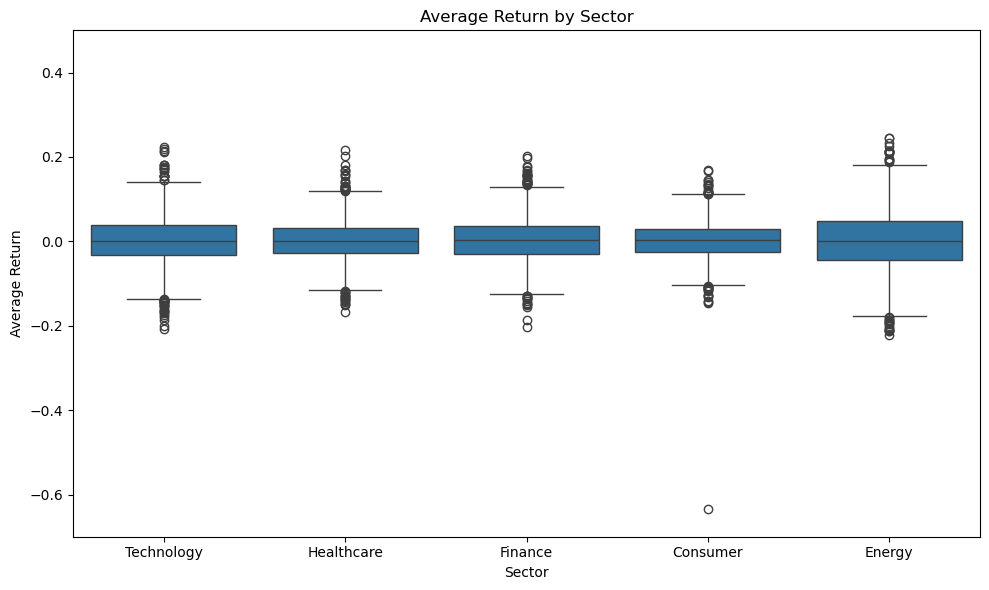

In [37]:
# Visualizing Sector Performance with box plots

plt.figure(figsize=(10,6))
sns.boxplot(x="sector", y="future_return_5d", data=df)

plt.title("Average Return by Sector")
plt.xlabel("Sector")
plt.ylabel("Average Return")

plt.ylim(-0.7, 0.5)
plt.tight_layout()
plt.show()

#### 3. Volume Analysis

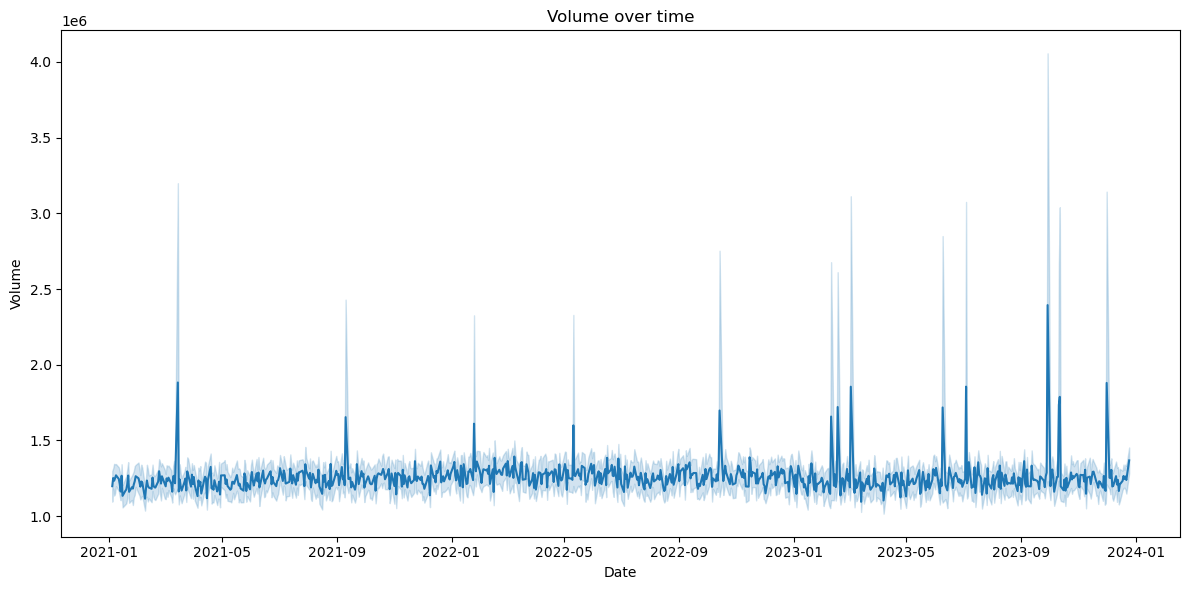

In [39]:
# a. Volume Patterns over time

plt.figure(figsize=(12,6))
sns.lineplot(x="date", y="volume", data=df)

plt.title("Volume over time")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.tight_layout()
plt.show()

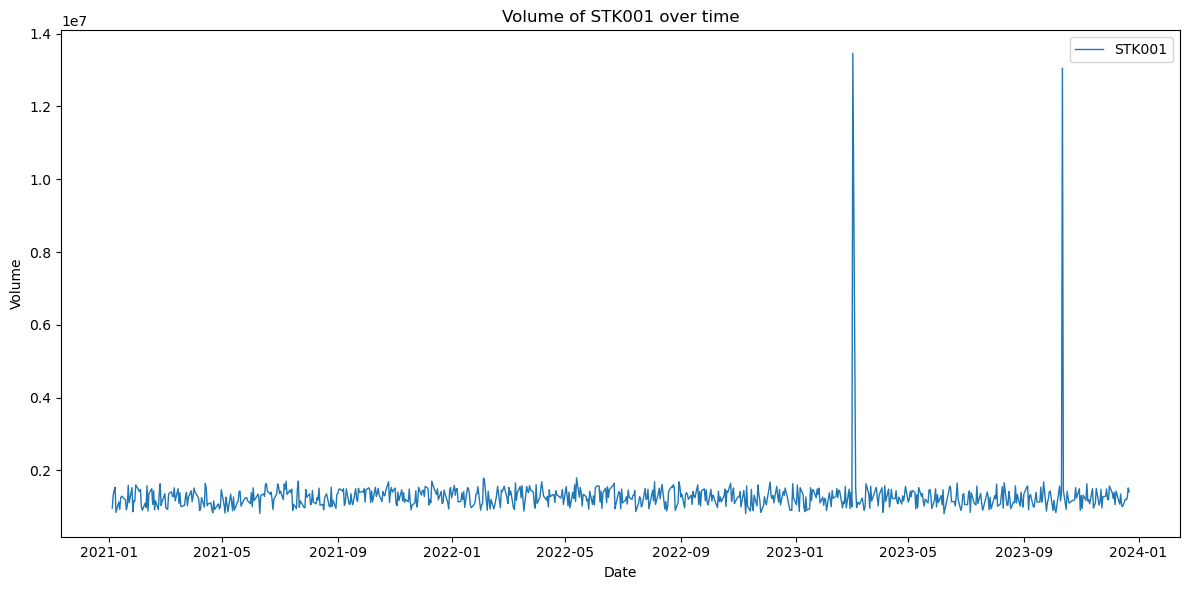

In [40]:
plt.figure(figsize=(12,6))
sns.lineplot(x="date", y="volume", data=df[df["ticker"]=="STK001"], label='STK001', linewidth=1)

plt.title("Volume of STK001 over time")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.tight_layout()
plt.show()

In [41]:
# High volume days (top 20)

df.groupby("date")["volume"].sum().sort_values(ascending=False).head(5)

date
2023-09-29    4.787752e+07
2021-03-15    3.765669e+07
2023-12-01    3.759849e+07
2023-07-04    3.710914e+07
2023-03-03    3.710142e+07
Name: volume, dtype: float64

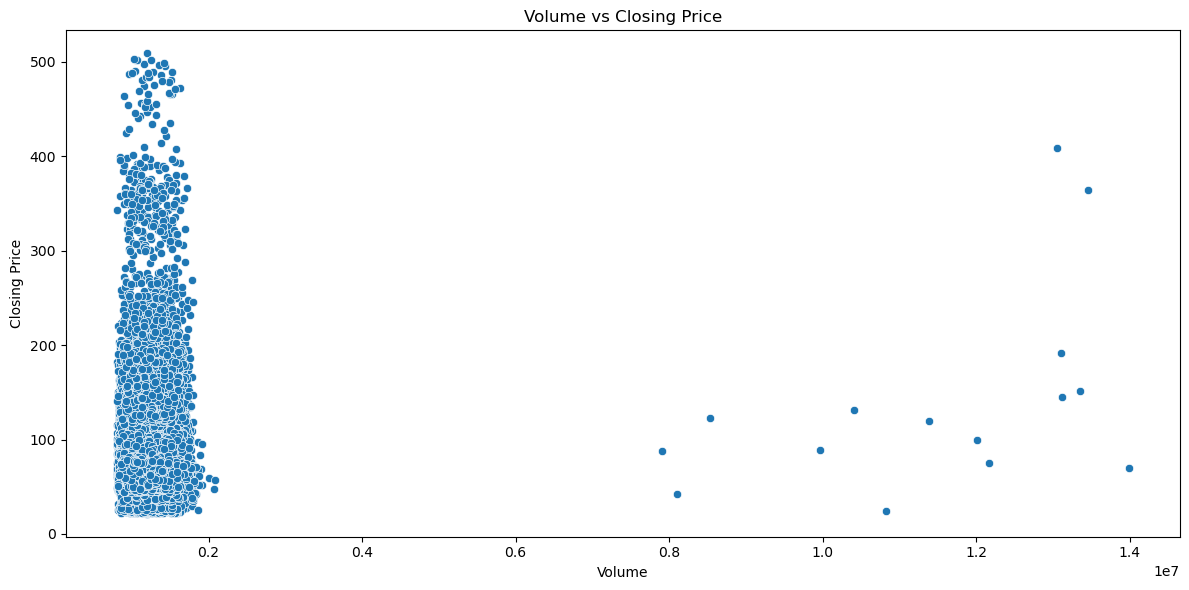

In [42]:
# Relationship between volume and price

plt.figure(figsize=(12,6))
sns.scatterplot(x="volume", y="close", data=df)

plt.xlabel('Volume')
plt.ylabel('Closing Price')
plt.title('Volume vs Closing Price')

plt.tight_layout()
plt.show()

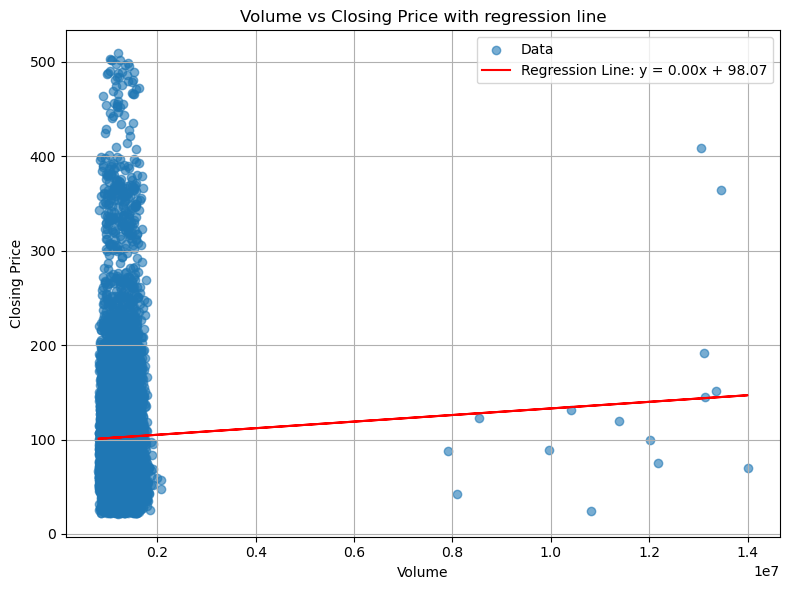

In [43]:
# Relationship between volume and price with regression line

x = df['volume']
y = df['close']
m, b = np.polyfit(x, y, deg=1)

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.6, label='Data')

plt.plot(x, m*x + b, color='red', label=f'Regression Line: y = {m:.2f}x + {b:.2f}')

plt.xlabel('Volume')
plt.ylabel('Closing Price')
plt.title('Volume vs Closing Price with regression line')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


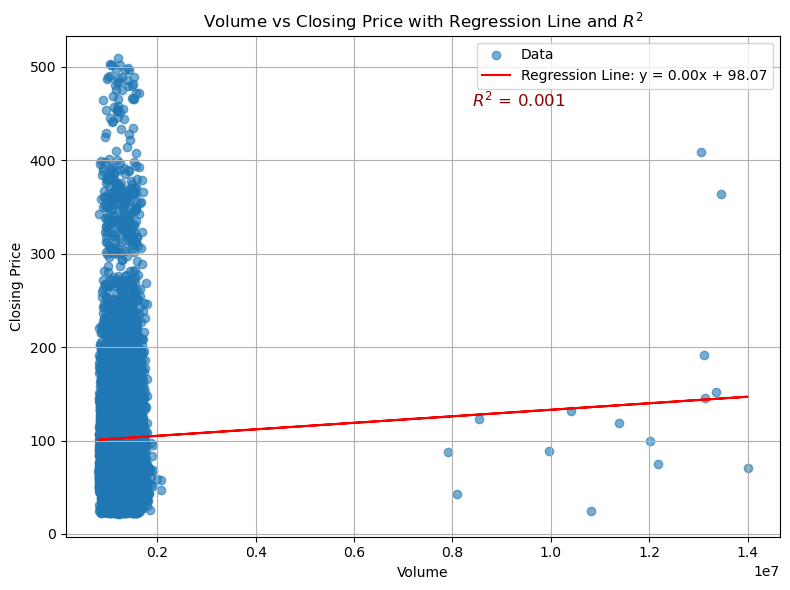

In [44]:
# Relationship between volume and price with regression line and R² (correlation coefficient)

x = df['volume']
y = df['close']

# Fit linear regression
m, b = np.polyfit(x, y, deg=1)
y_pred = m * x + b

# Calculate R²
correlation_matrix = np.corrcoef(x, y)
r = correlation_matrix[0, 1]
r_squared = r**2

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.6, label='Data')
plt.plot(x, y_pred, color='red', label=f'Regression Line: y = {m:.2f}x + {b:.2f}')

# Annotate R² on the plot
plt.text(x.max()*0.6, y.max()*0.9, f'$R^2$ = {r_squared:.3f}', fontsize=12, color='darkred')

# Final touches
plt.xlabel('Volume')
plt.ylabel('Closing Price')
plt.title('Volume vs Closing Price with Regression Line and $R^2$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


##### To quantify the relationship:
- A value near 0 → no relationship
- Positive → higher volume tends to occur with higher prices
- Negative → higher volume tends to occur with lower prices

In [46]:
# c. Calculating correlation between volume and price movement (CLOSING PRICE)

correlation_vol_close = df['volume'].corr(df['close'])
print(correlation_vol_close)


0.023116947306642262


In [47]:
# Calculating correlation between volume and price movement (RSI_14)

correlation_vol_rsi = df["volume"].corr(df["rsi_14"])
print(correlation_vol_rsi)

0.011717553963022619


#### 4. Technical Indicator Exploration

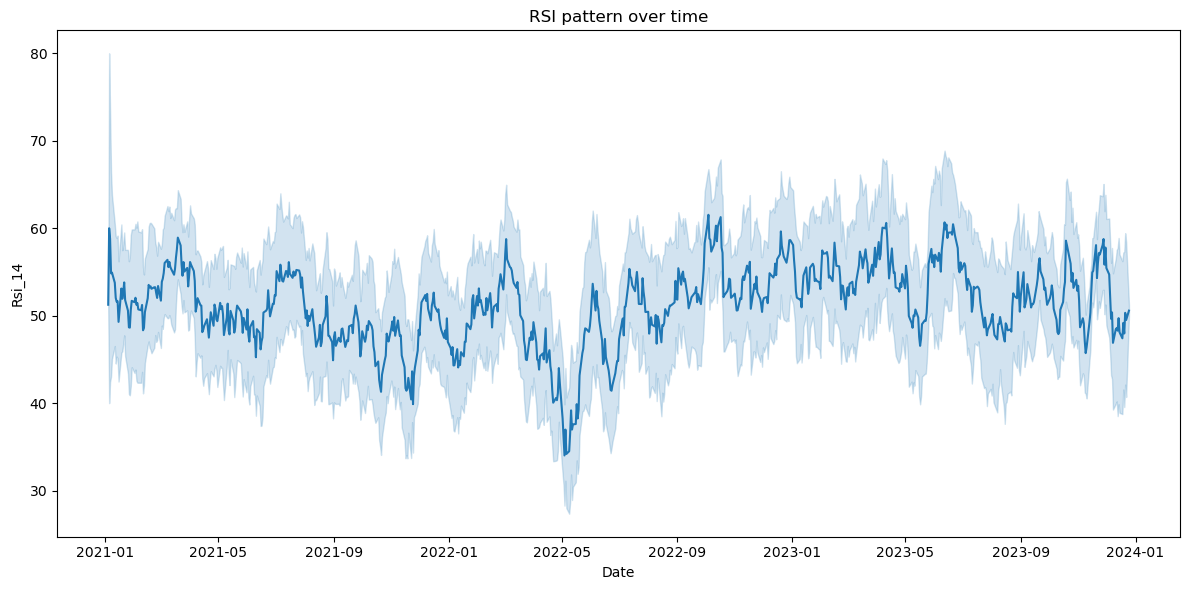

In [49]:
# a. RSI patterns visualization (Overbought/oversold conditions)

plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='rsi_14', data=df) 
plt.xlabel('Date')
plt.ylabel('Rsi_14')
plt.title('RSI pattern over time')

plt.tight_layout()
plt.show()

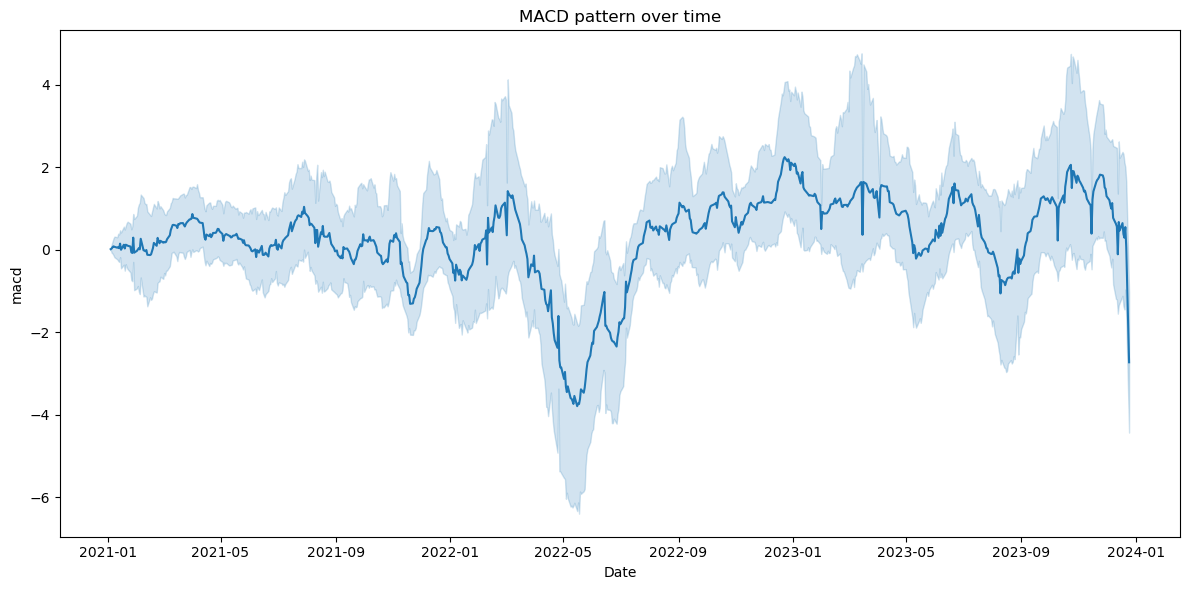

In [50]:
# b. MACD crossovers patterns

plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='macd', data=df) 
plt.xlabel('Date')
plt.ylabel('macd')
plt.title('MACD pattern over time')

plt.tight_layout()
plt.show()


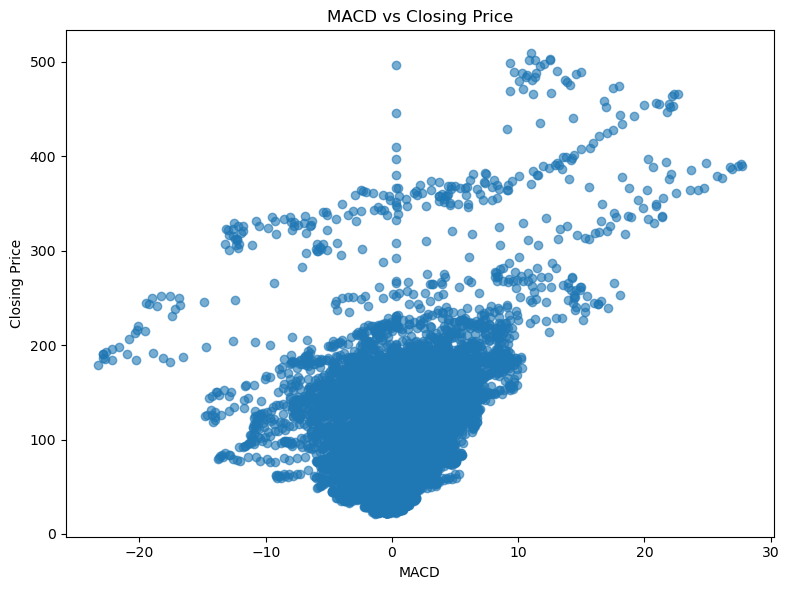

In [51]:
# MACD crossovers and relationship to price trends

plt.figure(figsize=(8, 6))
plt.scatter(df['macd'], df['close'], alpha=0.6) 

plt.xlabel('MACD')
plt.ylabel('Closing Price')
plt.title('MACD vs Closing Price')

plt.tight_layout()
plt.show()


In [52]:
correlation_macd_close = df["macd"].corr(df["close"])
print(correlation_macd_close)

0.33278118969257725


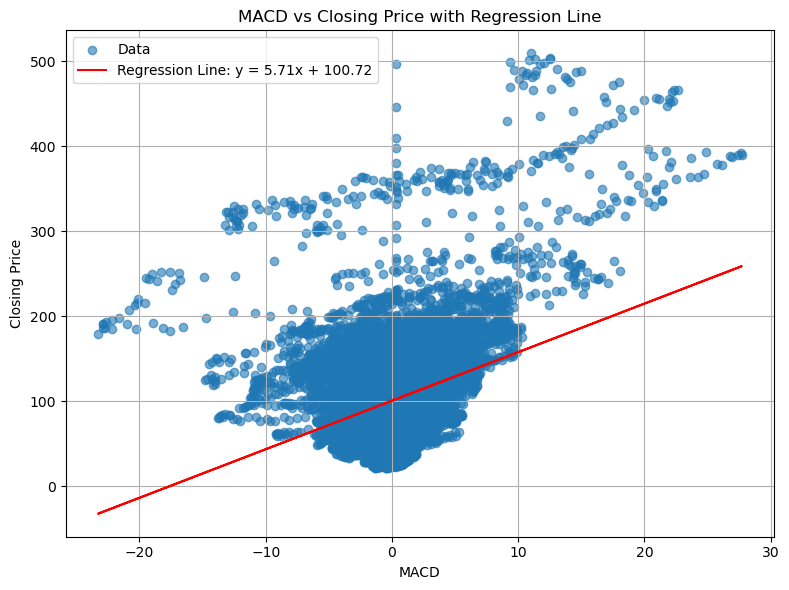

In [53]:

# Fit linear regression: y = m*x + b

x = df['macd']

y = df['close']
m, b = np.polyfit(x, y, deg=1)  # Linear fit

# Plot scatter
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.6, label='Data')

# Plot regression line
plt.plot(x, m*x + b, color='red', label=f'Regression Line: y = {m:.2f}x + {b:.2f}')

# Labels and title
plt.xlabel('MACD')
plt.ylabel('Closing Price')
plt.title('MACD vs Closing Price with Regression Line')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


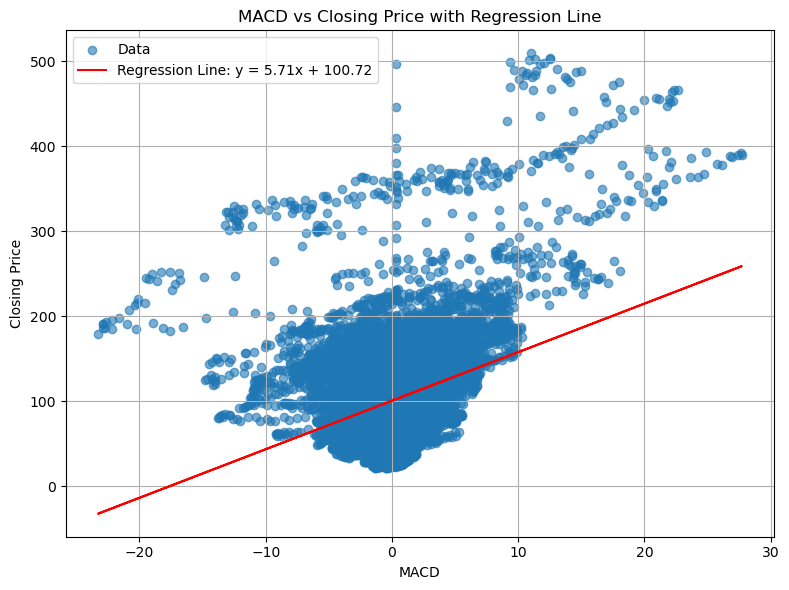

In [54]:
# MACD crossovers and relationship to price trends with regression line

x = df['macd']
y = df['close']
m, b = np.polyfit(x, y, deg=1)

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.6, label='Data')

plt.plot(x, m*x + b, color='red', label=f'Regression Line: y = {m:.2f}x + {b:.2f}')

plt.xlabel('MACD')
plt.ylabel('Closing Price')
plt.title('MACD vs Closing Price with Regression Line')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


##### Comparing R² across indicators

In [56]:
# Comparing R² across indicators

# import numpy as np
# import pandas as pd

# List of indicators to test
indicators = ['macd', 'rsi_14', 'volume', 'sma_20', 'bb_middle', 'bb_upper', 'bb_lower']  # Add more as needed

# Prepare a dictionary to store R² values
r2_scores = {}

# Loop through each indicator
for col in indicators:
    df_clean = df[[col, 'close']].dropna()
    x = df_clean[col]
    y = df_clean['close']
    
    if len(df_clean) > 1:
        r = np.corrcoef(x, y)[0, 1]
        r2_scores[col] = r**2
    else:
        r2_scores[col] = np.nan  # Not enough data

# Convert to DataFrame and sort
r2_df = pd.DataFrame.from_dict(r2_scores, orient='index', columns=['R_squared'])
r2_df = r2_df.sort_values(by='R_squared', ascending=False)

print(r2_df)


           R_squared
bb_middle   0.985095
bb_upper    0.979234
bb_lower    0.976643
sma_20      0.968676
macd        0.110743
rsi_14      0.015261
volume      0.000534


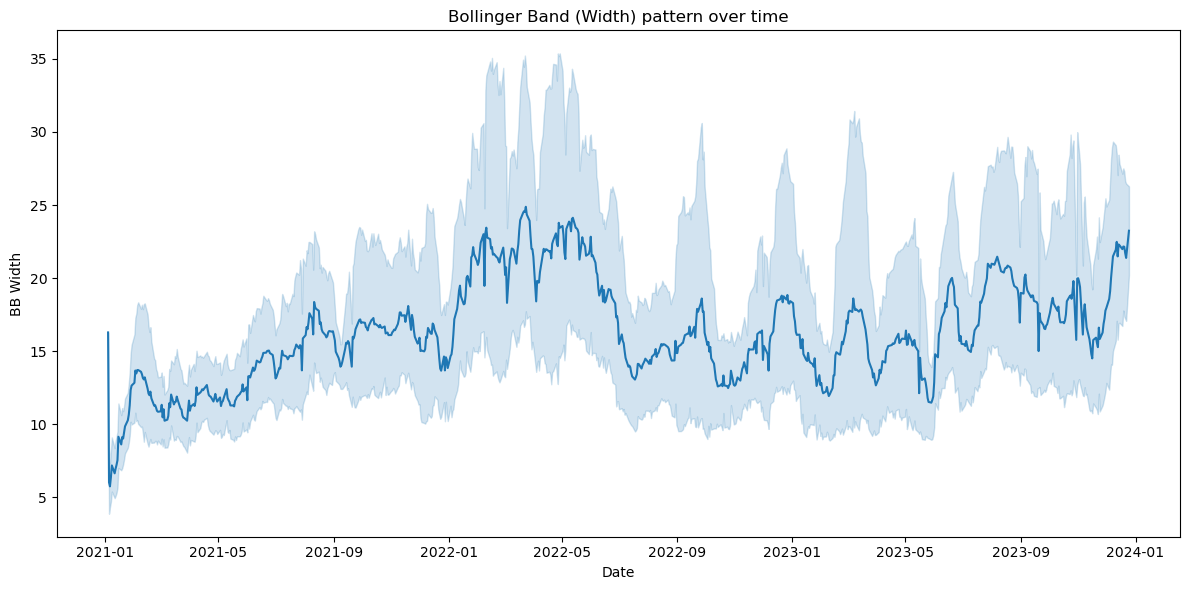

In [57]:
# c. Bollinger Band (Width) patterns

plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y="bb_width", data=df) 
plt.xlabel('Date')
plt.ylabel('BB Width')
plt.title('Bollinger Band (Width) pattern over time')

plt.tight_layout()
plt.show()

#### 5. Correlation Analysis

In [59]:
df.columns

Index(['ticker', 'company_name', 'sector', 'ipo_date', 'date', 'open', 'high',
       'low', 'close', 'volume', 'adjusted_close', 'sma_20', 'sma_50',
       'sma_200', 'ema_12', 'ema_26', 'macd', 'macd_signal', 'macd_histogram',
       'rsi_14', 'bb_middle', 'bb_upper', 'bb_lower', 'bb_width', 'true_range',
       'atr_14', 'volume_sma_20', 'volume_ratio', 'momentum_10', 'momentum_20',
       'price_to_sma_50', 'volatility_20', 'future_return_5d', 'trend_label'],
      dtype='object')

In [60]:
# Correlation heatmap of selected features

columns_heatmap = df[['close', 'volume', 'sma_20', 'sma_50', 'sma_200', 'ema_12', 'ema_26', 'macd', 'macd_signal', 'macd_histogram',
                   'rsi_14', 'bb_middle', 'bb_upper', 'bb_lower', 'bb_width', 'true_range', 'atr_14', 'volume_sma_20', 'volume_ratio',
                   'momentum_10', 'momentum_20', 'price_to_sma_50', 'volatility_20', 'future_return_5d']]


In [61]:
columns_heatmap.head(2)

,close,volume,sma_20,sma_50,sma_200,ema_12,ema_26,macd,macd_signal,macd_histogram,...,bb_width,true_range,atr_14,volume_sma_20,volume_ratio,momentum_10,momentum_20,price_to_sma_50,volatility_20,future_return_5d
0,160.11,962644.0,160.110,160.110,160.110,160.110000,160.110000,0.000000,0.000000,0.00000,...,16.282274,2.88,2.880,962644.0,1.000000,0.005172,0.010515,0.000000,0.022965,0.026357
1,162.36,1312685.0,161.235,161.235,161.235,160.456154,160.276667,0.179487,0.035897,0.14359,...,6.363961,5.39,4.135,1137664.5,1.153842,0.005172,0.010515,0.006977,0.022965,0.018169


In [62]:
len(columns_heatmap.columns)

24

In [63]:
correlation_map = columns_heatmap.corr()

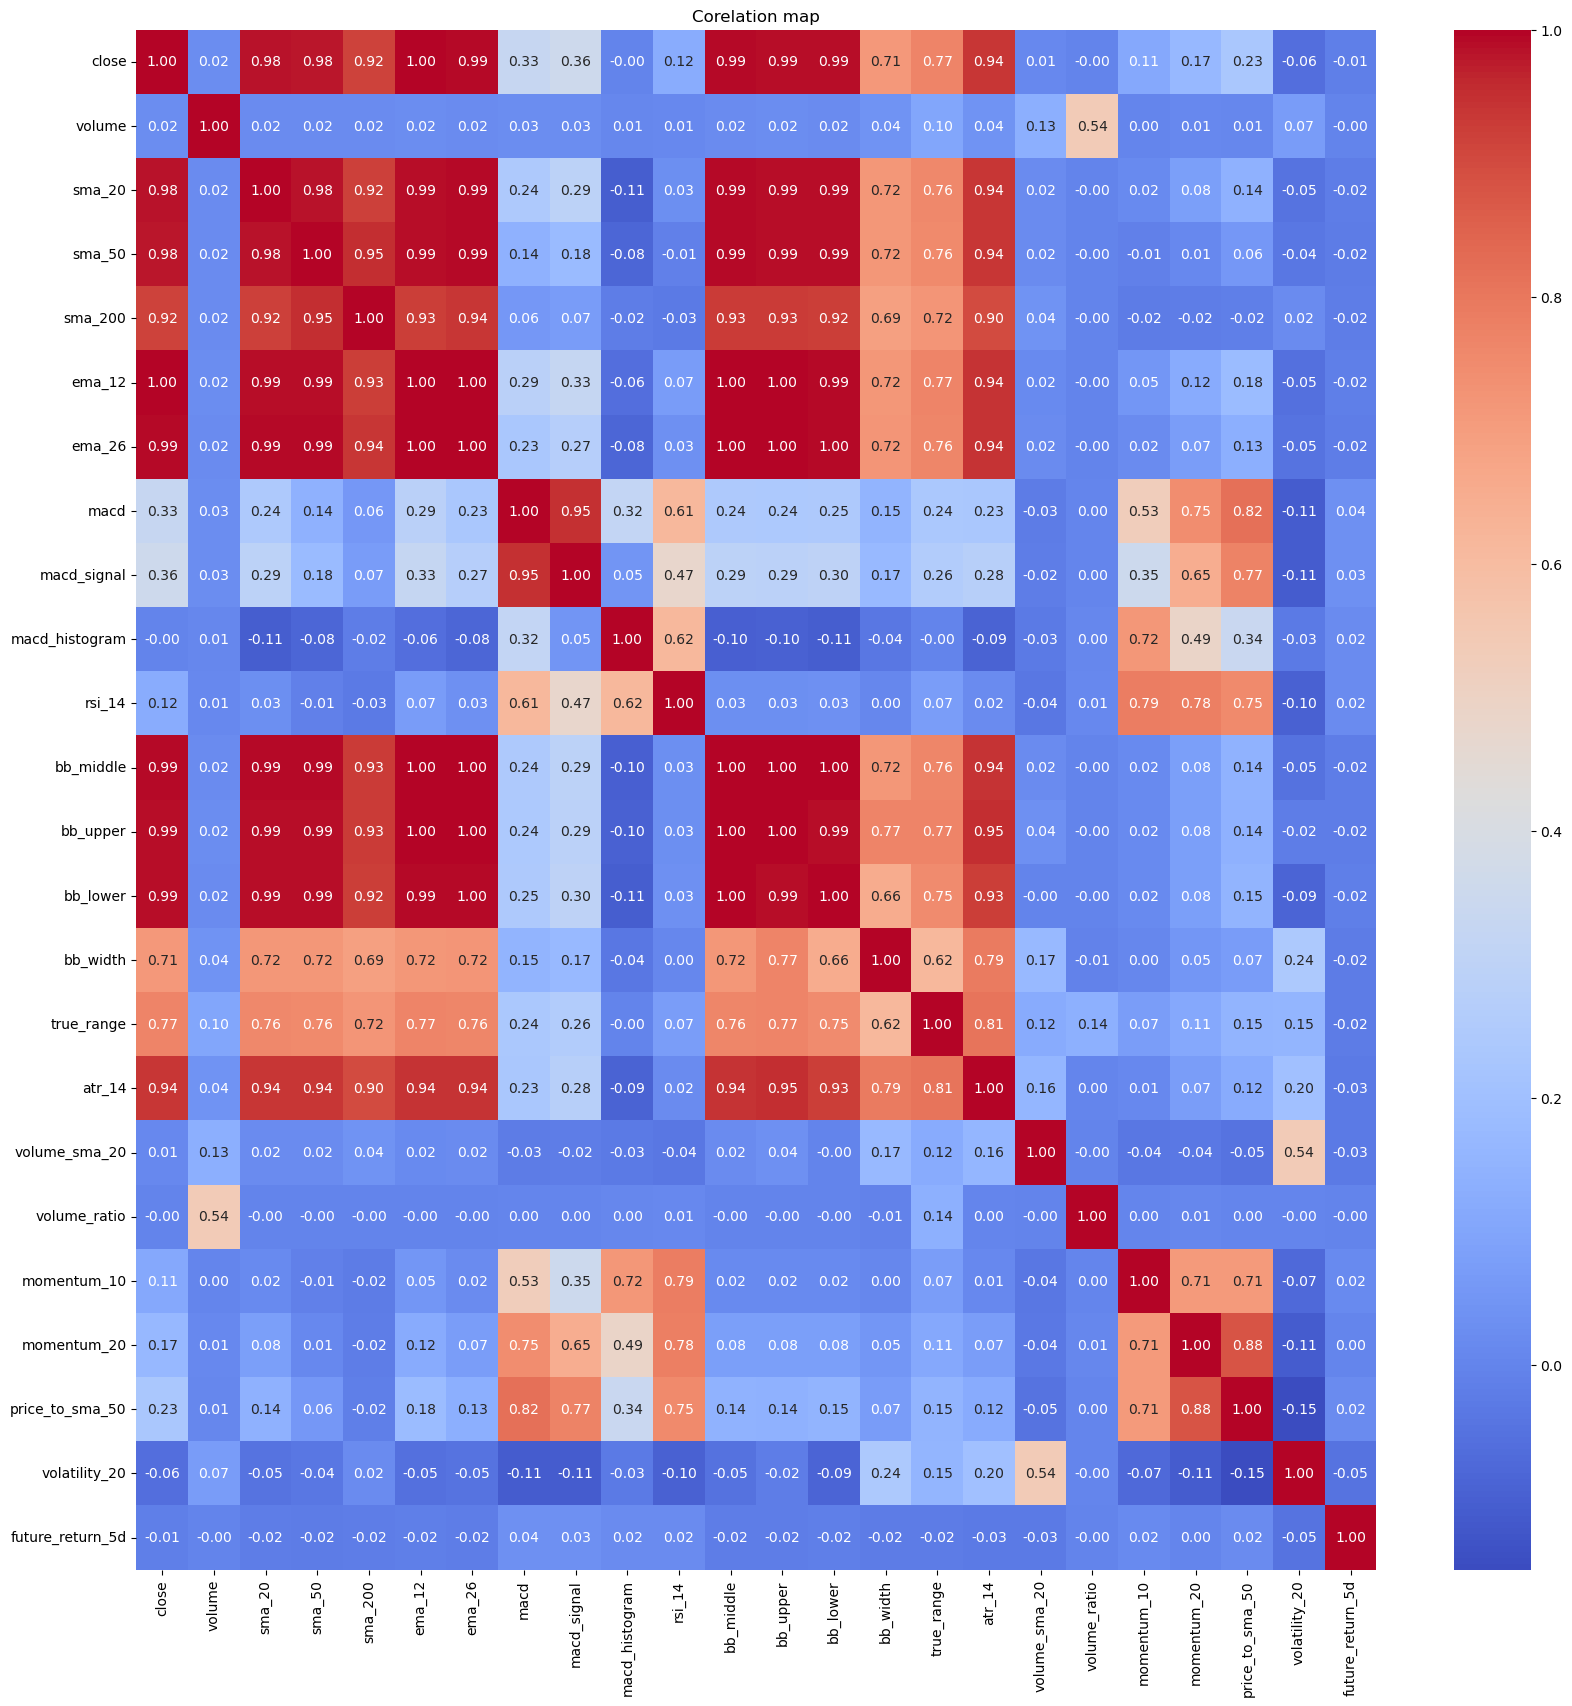

In [64]:
plt.figure(figsize=(20,20))
sns.heatmap(correlation_map, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Corelation map")
plt.show()

In [65]:
# Correlation heatmap for selected columns

select_col_heatmap = df[['close', 'volume', 'sma_20', 'ema_26', 'macd', 'rsi_14', 'bb_width',
                         'atr_14', 'volume_sma_20', 'momentum_20', 'volatility_20', 'future_return_5d']]


In [66]:
select_corr_map = select_col_heatmap.corr()

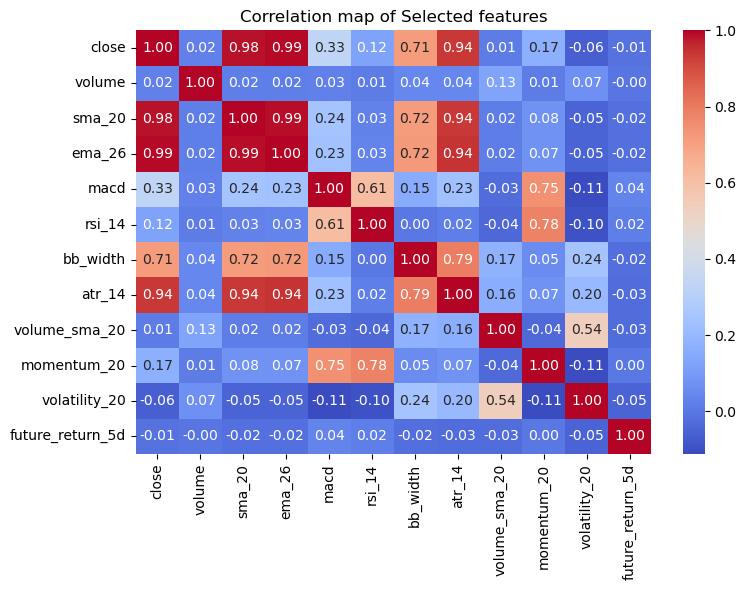

In [67]:

plt.figure(figsize=(8,6))
sns.heatmap(select_corr_map, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation map of Selected features")

plt.tight_layout()
plt.show()